In [2]:
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [3]:
# Tamaño de la BD
dataset.shape

(398, 8)

In [4]:
# Contar número de nulos
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

Caballos de fuerza tiene nulos, y no puedo tenerlos para el modelo. Los quito

In [5]:
dataset = dataset.dropna() # Borra NA
dataset.isna().sum() # Verificamos

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

La columna origin es una categoria (origen del auto), solo que esta codificada con numeros, pero entonces no la podemos usar como variable numerica, asi aparezca como numeros...

In [6]:
dataset.Origin.unique()

array([1, 3, 2], dtype=int64)

In [7]:
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset["Origin"].value_counts() #Contamos valores para cada categoria

Origin
1    245
3     79
2     68
Name: count, dtype: int64

Vamos a transformar esta variable a categoria, q es lo q es

In [8]:
# Forma 1 (como no deberia hacerse, no recomendado)

dataset["Origin"] = dataset["Origin"].map(
    {
        1: "USA",
        2: "Europe",
        3: "Japan"
    }
)

# Lo que se hizo fue, usar la funcion map, y uso un diccionario (calves y llaves el 1,2,3 con sus respectivos paises). 
# Otra forma es con replace pero seria una linea por cada categoria

dataset.head(10)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA
5,15.0,8,429.0,198.0,4341.0,10.0,70,USA
6,14.0,8,454.0,220.0,4354.0,9.0,70,USA
7,14.0,8,440.0,215.0,4312.0,8.5,70,USA
8,14.0,8,455.0,225.0,4425.0,10.0,70,USA
9,15.0,8,390.0,190.0,3850.0,8.5,70,USA


Para estadistica estaria "bien" ya q se cumplio con transformar la variable categorica... Pero hay un problema, cuando se llegue a la parte de test o en un futuro, q va pasar cuando salga un valor diferente a los codificados (ej: un 0, 4, 10...), no se esta manejando ese problema y la aplicacion se cae.

A un modelo de regresion tampoco puedo meter strings. Usemos variables dummies. Usaremos la transformacion: One hot encoding

Por cada categoria agregara una nueva columna y se pondra 1 donde corresponde... (variable indicadora). Aca no usamos categoria de referencia

In [9]:
# Genera variables dummy para indicar la procedencia (Pésima solución)

dataset = pd.get_dummies(dataset, columns = ["Origin"], prefix = "", prefix_sep = "")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


Lo anterior esta mal

- Mala solución: las columnas dependen de las categorías presentes.
- Si aparece una categoría nueva o cambia el orden entre train/test/producción, las variables pueden no coincidir y el modelo puede fallar o interpretar mal los datos.

En resumen: El problema es que get_dummies() puede generar columnas diferentes entre entrenamiento y producción

Ademas hay un problema (lo q se dijo), primero debo partir mis datos en train-test. Si primero hago el analisis y luego divido pues el modelo va dar metricas muy buenas porque sabia q le iba evaluar (test)

In [10]:
# Note q no se usa train_test_split (es lo usual, solo se enseña esta alternativa)

train_dataset = dataset.sample(frac=0.8, random_state = 0)
test_dataset = dataset.drop(train_dataset.index) 

Ahora q si dividi mis datos, vamos a usar datos de entrenamiento... Hagamos un descriptivo (de nuevo, primero divida los datos y ahi si descriptivo). El descriptivo siempre hacerlo segun mi pregunta o lo q me interesa, nada de hacer todo lo q sepa y graficos-cosas a lo loco

c:\Users\ADMIN\Desktop\Semestre 8\Analitica\std-yeison-rivera-morales\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ADMIN\Desktop\Semestre 8\Analitica\std-yeison-rivera-morales\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ADMIN\Desktop\Semestre 8\Analitica\std-yeison-rivera-morales\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ADMIN\Desktop\Semestre 8\Analitica\std-y

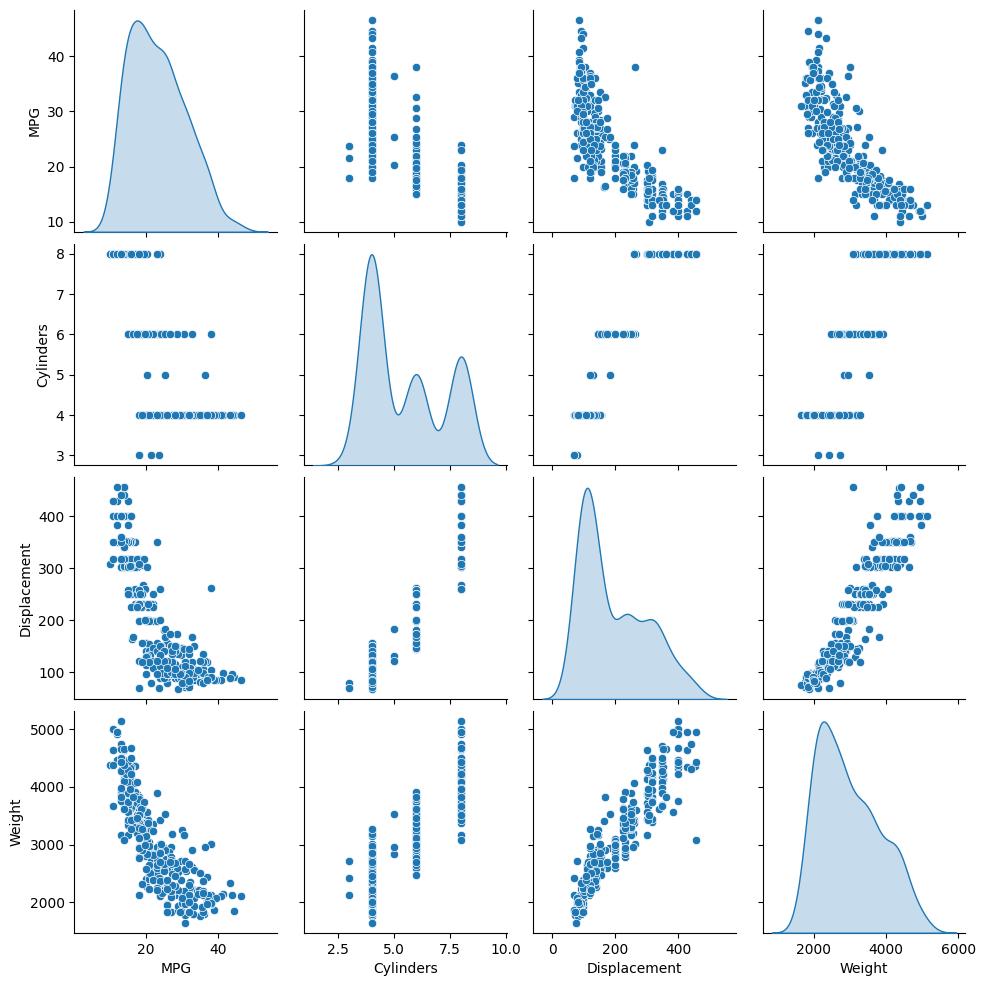

In [ ]:
# Las millas por galon (MPG) son función de las demas variables.

# No usaremos todas las variables, se tomaron 4. Entre mas poquitas mas facil analizar

import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)


In [ ]:
dataset["Cylinders"].unique() #variable discreta

array([8, 4, 6, 3, 5], dtype=int64)

In [14]:
# Calculando algunas estadisticas generales

train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [ ]:
# Particionamiento de los datos en features y labels

# Divido datos en X y Y

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG") # Pop elimina MPG de train_features y la mete a la nueva variable train_labels

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [17]:
# Estandarización de los datos (normalización)

train_dataset.describe().transpose()[["mean", "std"]]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


Vamos a normalizar las variables, se usara uno de tantos metodos (StandardScaler). 

$$
\frac{X-\mu}{\sigma}
$$

Quedando la media 0, desviacion estandar 1

In [23]:
# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]

,mean,std
MPG,-2.206303e-16,1.001596
Cylinders,2.022444e-16,1.001596
Displacement,7.990777e-17,1.001596
Horsepower,-1.980016e-17,1.001596
Weight,-9.051500e-17,1.001596
Acceleration,-5.275327e-16,1.001596
Model Year,9.419217e-16,1.001596
Europe,3.394312e-17,1.001596
Japan,2.828594e-18,1.001596
USA,1.697156e-17,1.001596


Note q la media es 0, la d.e = 1.

Para normalizar los datos de test debo usar la media y la d.e q ya guargo el transformer, no vuelvo a recalcular nada, uso los q use aqui con train. Mucho cuidado!!!

Primero haremos regresion lineal con 1 sola variable

In [26]:
# Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]  # X de entrenamiento
test_horsepower = test_features[["Horsepower"]]    # X de prueba

horsepower_scaler.fit(train_horsepower)  # Aprendo media y desviación estándar SOLO de train

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)  # Estandarizo X de train
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)    # Estandarizo X de test usando el scaler de train

In [ ]:
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression() #creo una instancia del objeto
horsepower_model.fit(standarized_train_horsepower, train_labels) #regreison lineal (x,y)

LinearRegression()

Para extaer coeficientes del modelo, hacemos:

In [28]:
# Intercepto
horsepower_model.intercept_

23.31050955414013

In [ ]:
# Coeficientes
horsepower_model.coef_ #bota un array porque espera o puede haber varias covariables, en este caso solo 1

array([-5.89948889])

Simulemos nuevos datos para ver como predice

In [ ]:
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)}) # Genera o simula 251 datos nuevos para horsepower 
x.head()

,Horsepower
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0


In [ ]:
# Predicción

scaled_x = horsepower_scaler.transform(x) # Estandariza esos nuevos valores usando el mismo scaler que entrenaste con train.
y = horsepower_model.predict(scaled_x) # El modelo recibe esos nuevos valores y calcula la predicción de y para cada uno.
y[:5] #primeras 5 predicciones

array([39.57626034, 39.42115555, 39.26605075, 39.11094596, 38.95584117])

Hagamos un grafico para verlo mejor

In [32]:
import matplotlib.pyplot as plt

def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()

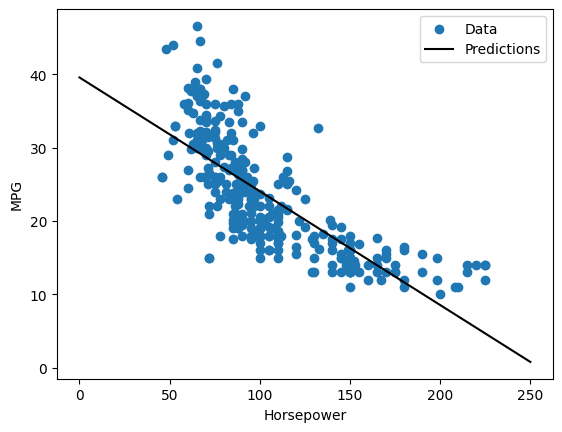

In [33]:
plot_horsepower(x, y)

Entre +potencia ---> +consumo. Todo el sentido del mundo, relacion negativa. Ademas va acorde a lo q se vio en descriptivo

In [ ]:
# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {} #diccionario para guardar resultado

y_pred = horsepower_model.predict(standarized_test_horsepower) # Predicciones del modelo usando los datos de test

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels, # Valores reales de test
    y_pred=y_pred, # Valores predichos por el modelo
)

test_results

{'horsepower_model': 20.829300555790315}

Error en testing fue de 20.83